In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode

In [ ]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-13h35.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)

MV


: 

In [ ]:
a = 0.08
e = 2.71828
t1 = 82
t2 = 110
Tu = 20
Tg = 240
Kp = 0.39888177525762775
Ts = 1

: 

In [ ]:
# Broida simple method (B sp)

: 

In [ ]:
T_Bsp = Tg
theta_Bsp = Tu
print(T_Bsp, theta_Bsp)

#step response
PV_Bsp = FOPDT(MVm, Kp, T_Bsp, theta_Bsp, Ts)


240 20


: 

In [ ]:
# More complicated method Broida (Bcm)

: 

In [ ]:
T_Bcm = 5.5*(t2 - t1)
theta_Bcm = 2.8*t1 - 1.8*t2
print(T_Bcm, theta_Bcm)

#step response
PV_Bcm = FOPDT(MVm, Kp, T_Bcm, theta_Bcm, Ts)

154.0 31.599999999999994


: 

In [ ]:
# van der Grinten model

: 

In [ ]:
T1_gm = Tg * (3*a*e - 1) / (1 + a*e)
T2_gm = Tg * (1 - a*e) / (1 + a*e)
theta_gm = Tu - ((T1_gm * T2_gm) / (T1_gm + 3*T2_gm))
print (T1_gm)
print (T2_gm)
print (theta_gm)

#step response
 #comme T1 negatif, le systeme est instable


-68.52537868931311
154.26268934465654
46.81184268931312


: 

In [ ]:
# strejc

: 

In [ ]:
r = Tu/Tg
print(r)

0.08333333333333333


: 

In [ ]:
bn = 1.00
an =0.00
T = Tg/bn
Tuth = an*Tg
theta_st = Tu - Tuth
print(T, theta_st)

#STEP REPONSE
PV_st = FOPDT(MVm,Kp,T,theta_st,Ts)

240.0 20.0


: 

In [ ]:
# Optimal model : SOPDT

: 

In [ ]:
T1_SOPDT = 141.19063529216578
T2_SOPDT = 25.926978332435702
theta_SOPDT = 12.993882283441533
PV_SOPDT = SOPDT(MVm,Kp,T1_SOPDT,T2_SOPDT,theta_SOPDT, Ts)

: 

In [ ]:
# Optimal model : FOPDT

: 

In [ ]:
T_FOPDT = 152.4928689777531
theta_FOPDT = 31.795820382906488
PV_FOPDT = FOPDT(MVm,Kp,T_FOPDT,theta_FOPDT,Ts)

: 

NameError: name 'ax1' is not defined

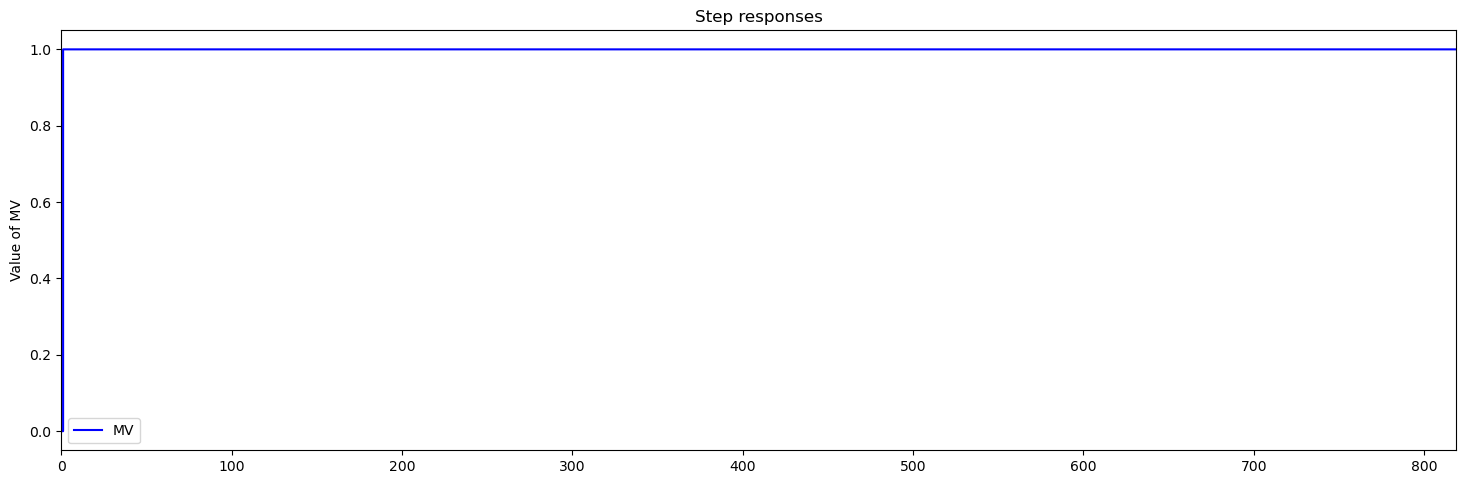

: 

In [ ]:
plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   


ax1.set_xlim(0, tm[-1]+1)
ax2.set_xlim(0, tm[-1]+1)
plt.subplot(2,1,2)

plt.step(tm,PV_Bsp,'g',label='Broida simple model',where='post')
plt.step(tm,PV_Bcm,'cyan',label='Boida Complicated model',where='post')
plt.step(tm,PV_SOPDT,'black',label='Optimal SOPDT',where='post')
plt.step(tm,PV_FOPDT,'pink',label='Optimal FOPDT',where='post')
#plt.step(tm,PV_gm,'lime',label='Van der Grinten model',where='post')
plt.step(tm,PV_st,'r',label='Strejc model',where='post')
plt.step(tm,PVm,'y',label='Experiment',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  


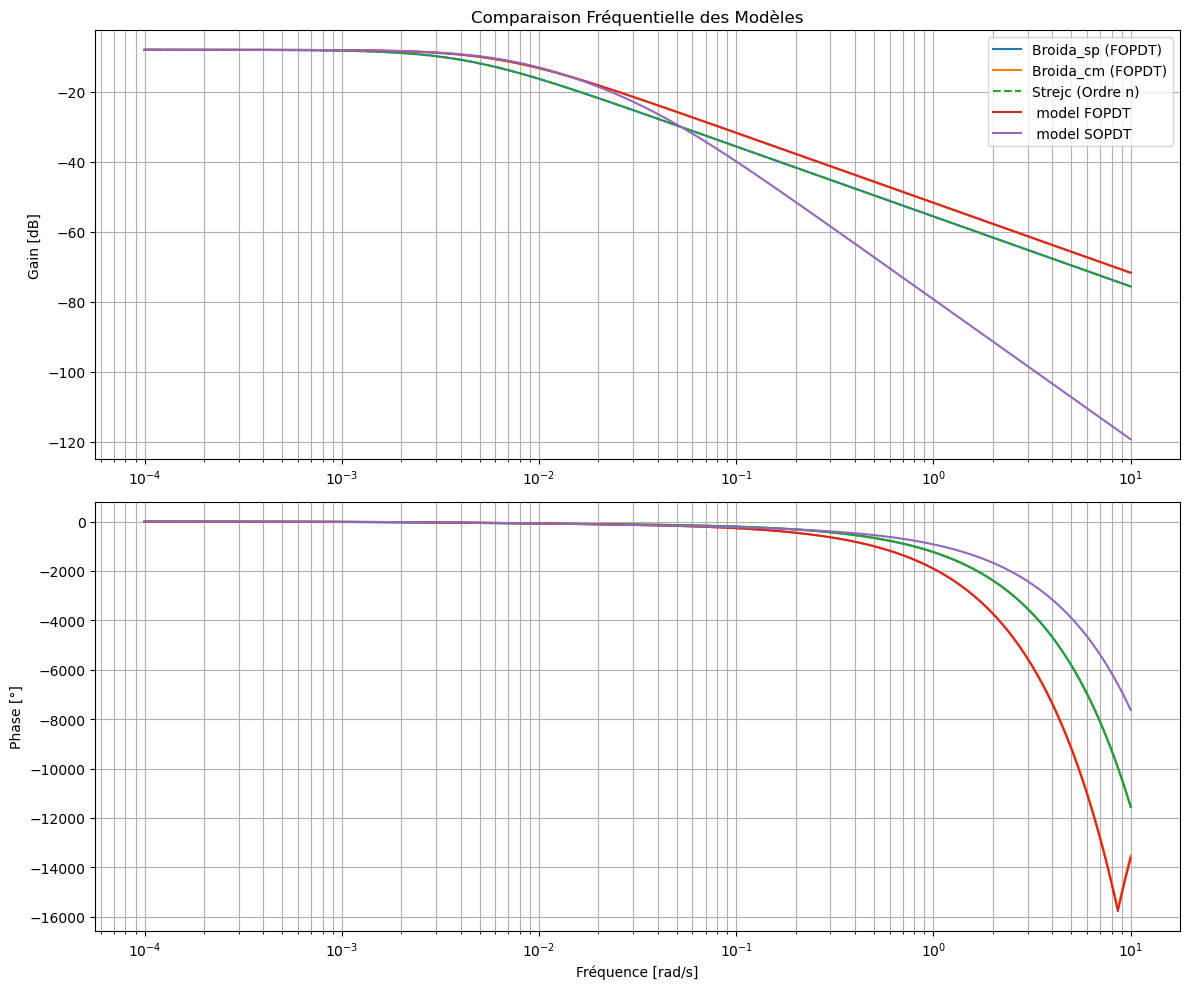

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fréquences d'analyse (échelle logarithmique)
omega = np.logspace(-4, 1, 1000) 

# 2. Modèle de Broida (FOPDT) - Issu de tes calculs t1, t2
P_Broida_sp = Process({})
P_Broida_sp.parameters['Kp'] = Kp  # Remplace par ta valeur
P_Broida_sp.parameters['Tlag1'] = T_Bsp 
P_Broida_sp.parameters['theta'] = theta_Bsp

# 3. Modèle de Broida (FOPDT) - Issu de tes calculs t1, t2
P_Broida_cm = Process({})
P_Broida_cm.parameters['Kp'] = Kp  # Remplace par ta valeur
P_Broida_cm.parameters['Tlag1'] = T_Bcm 
P_Broida_cm.parameters['theta'] = theta_Bcm

# 4. Modèle de Strejc (Ordre n) 
# Note : package_DBR supporte 2 lags, simule l'ordre n si n > 2 manuellement
P_Strejc = Process({})
P_Strejc.parameters['Kp'] = Kp
P_Strejc.parameters['Tlag1'] = T # T calculé
P_Strejc.parameters['theta'] = theta_st

#5. Modele SOPDT
P_SOPDT = Process({})
P_SOPDT.parameters['Kp'] = Kp
P_SOPDT.parameters['Tlag1'] = T1_SOPDT
P_SOPDT.parameters['Tlag2'] = T2_SOPDT
P_SOPDT.parameters['theta'] = theta_SOPDT

#.6 Modele FOPDT
P_FOPDT = Process({})
P_FOPDT.parameters['Kp'] = Kp
P_FOPDT.parameters['Tlag1'] = T_FOPDT
P_FOPDT.parameters['theta'] = theta_FOPDT

# Récupération des réponses fréquentielles
Ps_Broida_sp = Bode(P_Broida_sp, omega, Show=False)
Ps_Broida_cm = Bode(P_Broida_cm, omega, Show=False)
Ps_Strejc = Bode(P_Strejc, omega, Show=False)
P_FOPDT = Bode(P_FOPDT, omega, Show=False)
P_SOPDT = Bode(P_SOPDT, omega, Show=False)

# Création du graphique personnalisé
fig, (ax_gain, ax_phase) = plt.subplots(2, 1, figsize=(12, 10))

# --- Tracé de l'Amplitude (dB) ---
ax_gain.semilogx(omega, 20*np.log10(np.abs(Ps_Broida_sp)), label='Broida_sp (FOPDT)')
ax_gain.semilogx(omega, 20*np.log10(np.abs(Ps_Broida_cm)), label='Broida_cm (FOPDT)')
ax_gain.semilogx(omega, 20*np.log10(np.abs(Ps_Strejc)), label='Strejc (Ordre n)', linestyle='--')
ax_gain.semilogx(omega, 20*np.log10(np.abs(P_FOPDT)), label=' model FOPDT')
ax_gain.semilogx(omega, 20*np.log10(np.abs(P_SOPDT)), label=' model SOPDT')
ax_gain.set_ylabel('Gain [dB]')
ax_gain.set_title('Comparaison Fréquentielle des Modèles')
ax_gain.grid(True, which="both")
ax_gain.legend()

# --- Tracé de la Phase (°) ---
ax_phase.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_Broida_sp)), label='Broida_sp')
ax_phase.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_Broida_cm)), label='Broida_cm')
ax_phase.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_Strejc)), label='Strejc')
ax_phase.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(P_FOPDT)), label='model FOPDT')
ax_phase.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(P_SOPDT)), label='model SOPDT')
ax_phase.set_ylabel('Phase [°]')
ax_phase.set_xlabel('Fréquence [rad/s]')
ax_phase.grid(True, which="both")
plt.tight_layout()

In [ ]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_DV_2026-03-05-13h03.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)

DV


: 

In [ ]:
Kp_DV = 0.4221291122785367
Ts = 1
T_DV_FOPDT = 164.1660789220953
theta_DV_FOPDT = 21.52335112518307

: 

In [ ]:
# Optimal model for experience 2 (DVm) : FOPDT

: 

In [ ]:
T_DV_FOPDT = 164.1660789220953
theta_DV_FOPDT = 21.52335112518307
PV_DV_FOPDT = FOPDT(DVm,Kp_DV,T_DV_FOPDT,theta_DV_FOPDT,Ts)

: 

In [ ]:
# Optimal model for experience 2 (DVm) : SOPDT

: 

In [ ]:
T1_DV_SOPDT = 159.4756163039975
T2_DV_SOPDT = 17.613888176740733
theta_DV_SOPDT = 21.52335112518307
PV_DV_SOPDT = SOPDT(DVm,Kp_DV,T1_DV_SOPDT,T2_DV_SOPDT,theta_DV_SOPDT, Ts)

: 

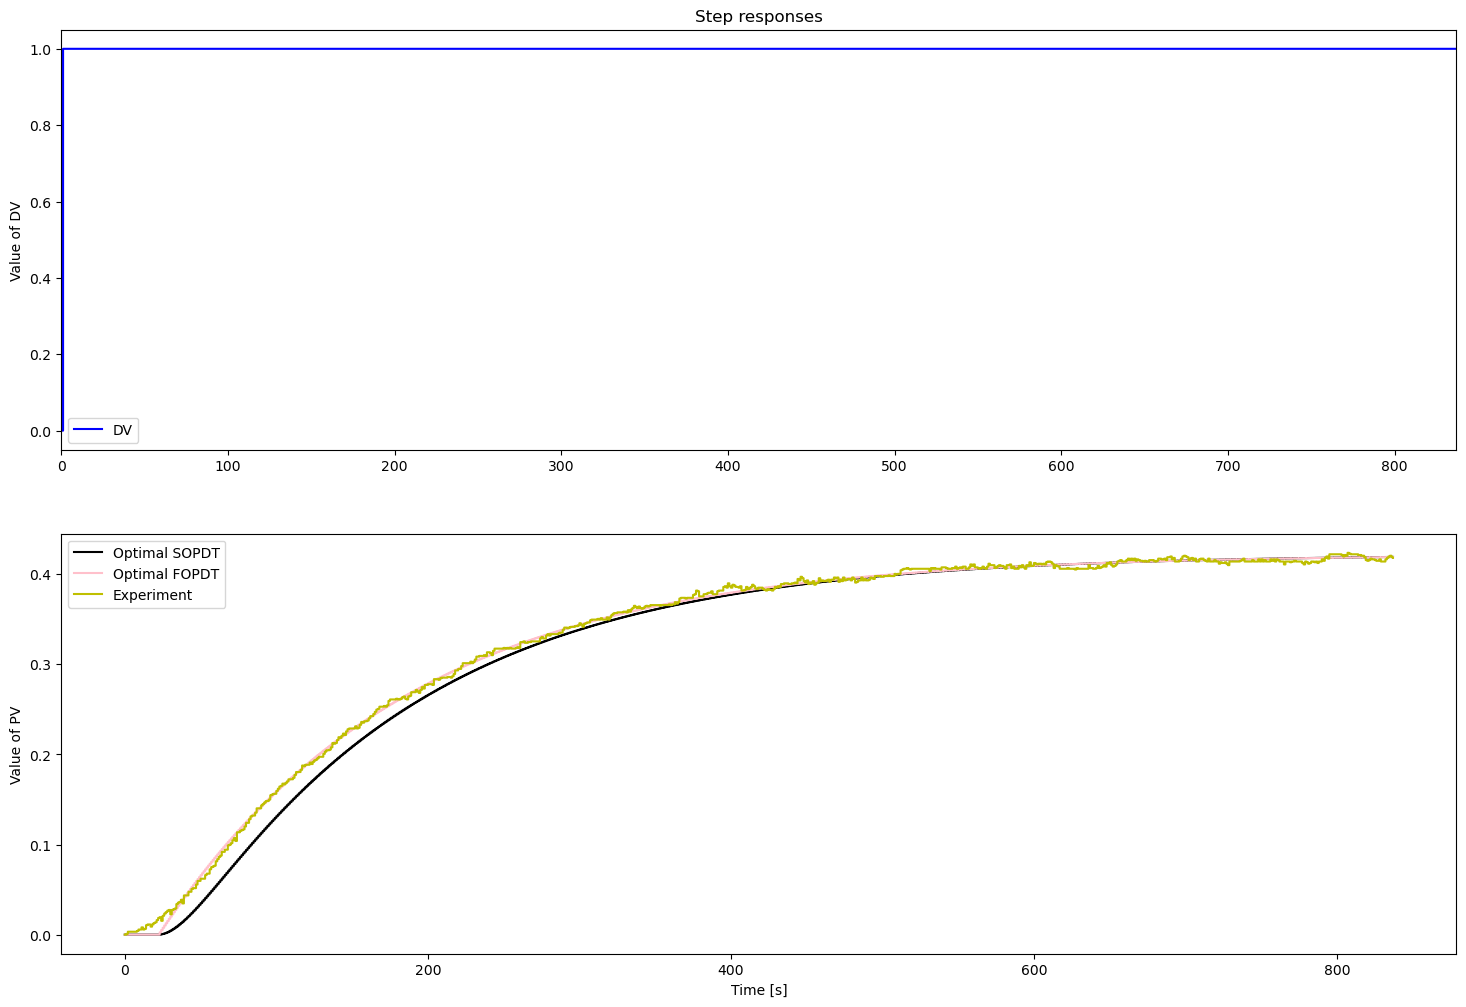

: 

In [ ]:
plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,DVm,'b-',label='DV',where='post')
plt.ylabel('Value of DV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   


ax1.set_xlim(0, tm[-1]+1)
ax2.set_xlim(0, tm[-1]+1)
plt.subplot(2,1,2)


plt.step(tm,PV_DV_SOPDT,'black',label='Optimal SOPDT',where='post')
plt.step(tm,PV_DV_FOPDT,'pink',label='Optimal FOPDT',where='post')
#plt.step(tm,PV_gm,'lime',label='Van der Grinten model',where='post')
#plt.step(tm,PV_st,'r',label='Strejc model',where='post')
plt.step(tm,PVm,'y',label='Experiment',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')

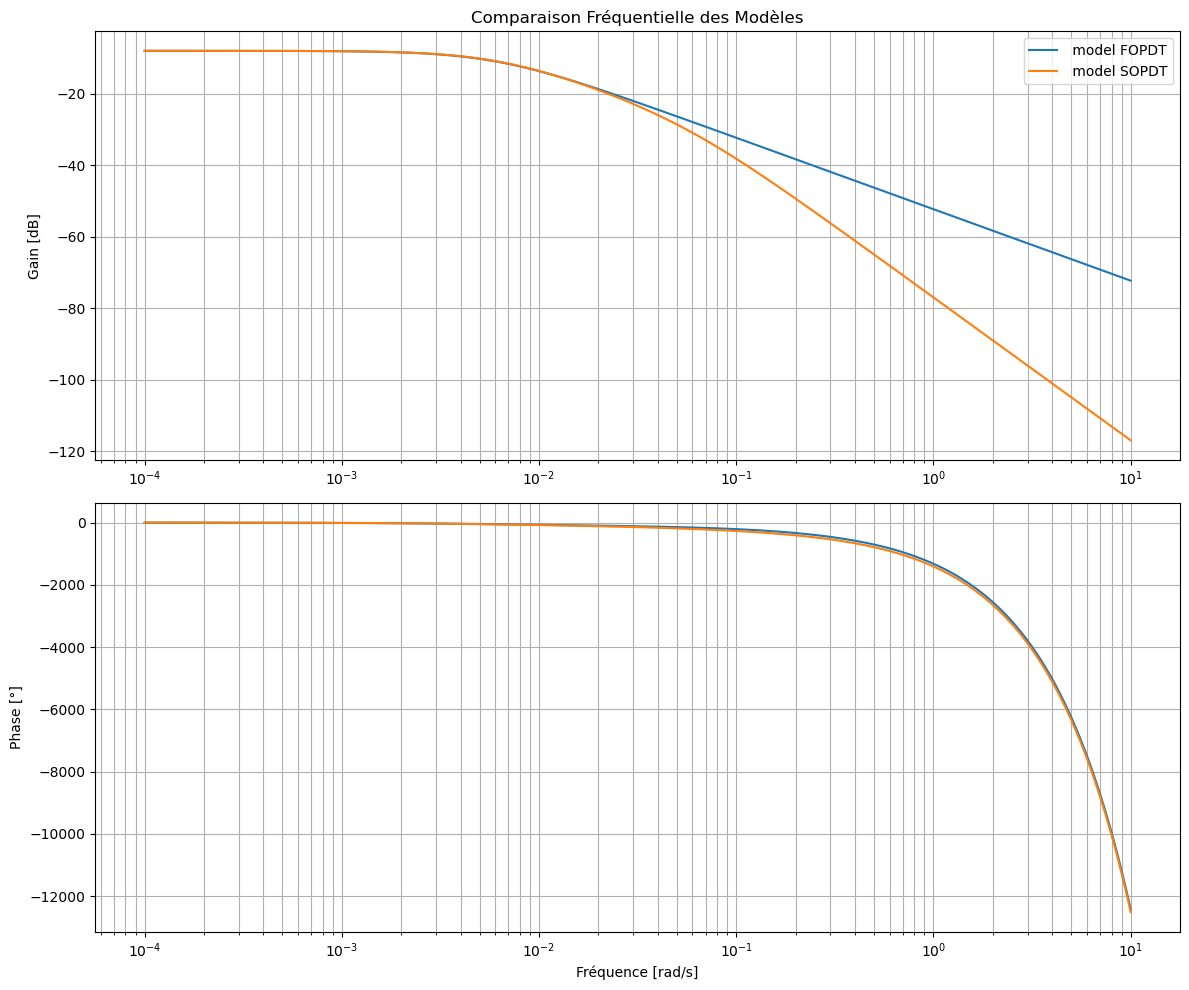

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Fréquences d'analyse (échelle logarithmique)
omega = np.logspace(-4, 1, 1000)

#2. Modele SOPDT
P_DV_SOPDT = Process({})
P_DV_SOPDT.parameters['Kp'] = Kp
P_DV_SOPDT.parameters['Tlag1'] = T1_DV_SOPDT
P_DV_SOPDT.parameters['Tlag2'] = T2_DV_SOPDT
P_DV_SOPDT.parameters['theta'] = theta_DV_SOPDT

#3. Modele FOPDT
P_DV_FOPDT = Process({})
P_DV_FOPDT.parameters['Kp'] = Kp
P_DV_FOPDT.parameters['Tlag1'] = T_DV_FOPDT
P_DV_FOPDT.parameters['theta'] = theta_DV_FOPDT

# Récupération des réponses fréquentielles
P_DV_FOPDT = Bode(P_DV_FOPDT, omega, Show=False)
P_DV_SOPDT = Bode(P_DV_SOPDT, omega, Show=False)

# Création du graphique personnalisé
fig, (ax_gain, ax_phase) = plt.subplots(2, 1, figsize=(12, 10))

# --- Tracé de l'Amplitude (dB) ---
ax_gain.semilogx(omega, 20*np.log10(np.abs(P_DV_FOPDT)), label=' model FOPDT')
ax_gain.semilogx(omega, 20*np.log10(np.abs(P_DV_SOPDT)), label=' model SOPDT')
ax_gain.set_ylabel('Gain [dB]')
ax_gain.set_title('Comparaison Fréquentielle des Modèles')
ax_gain.grid(True, which="both")
ax_gain.legend()

# --- Tracé de la Phase (°) ---
ax_phase.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(P_DV_FOPDT)), label='model FOPDT')
ax_phase.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(P_DV_SOPDT)), label='model SOPDT')
ax_phase.set_ylabel('Phase [°]')
ax_phase.set_xlabel('Fréquence [rad/s]')
ax_phase.grid(True, which="both")
plt.tight_layout()

In [ ]:
nameFile = 'Open_loop_experiment_on_MV_2026-03-03-13h35.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)
if 'MV' in nameFile:
    ExpVariable = 'MV'
    t = data['t'].values
    MV = data['MV'].values
    PV = data['PV'].values    
else:    
    ExpVariable = 'DV'
    t = data['t'].values
    DV = data['DV'].values 
    PV = data['PV'].values
     
print(ExpVariable)

MV


: 

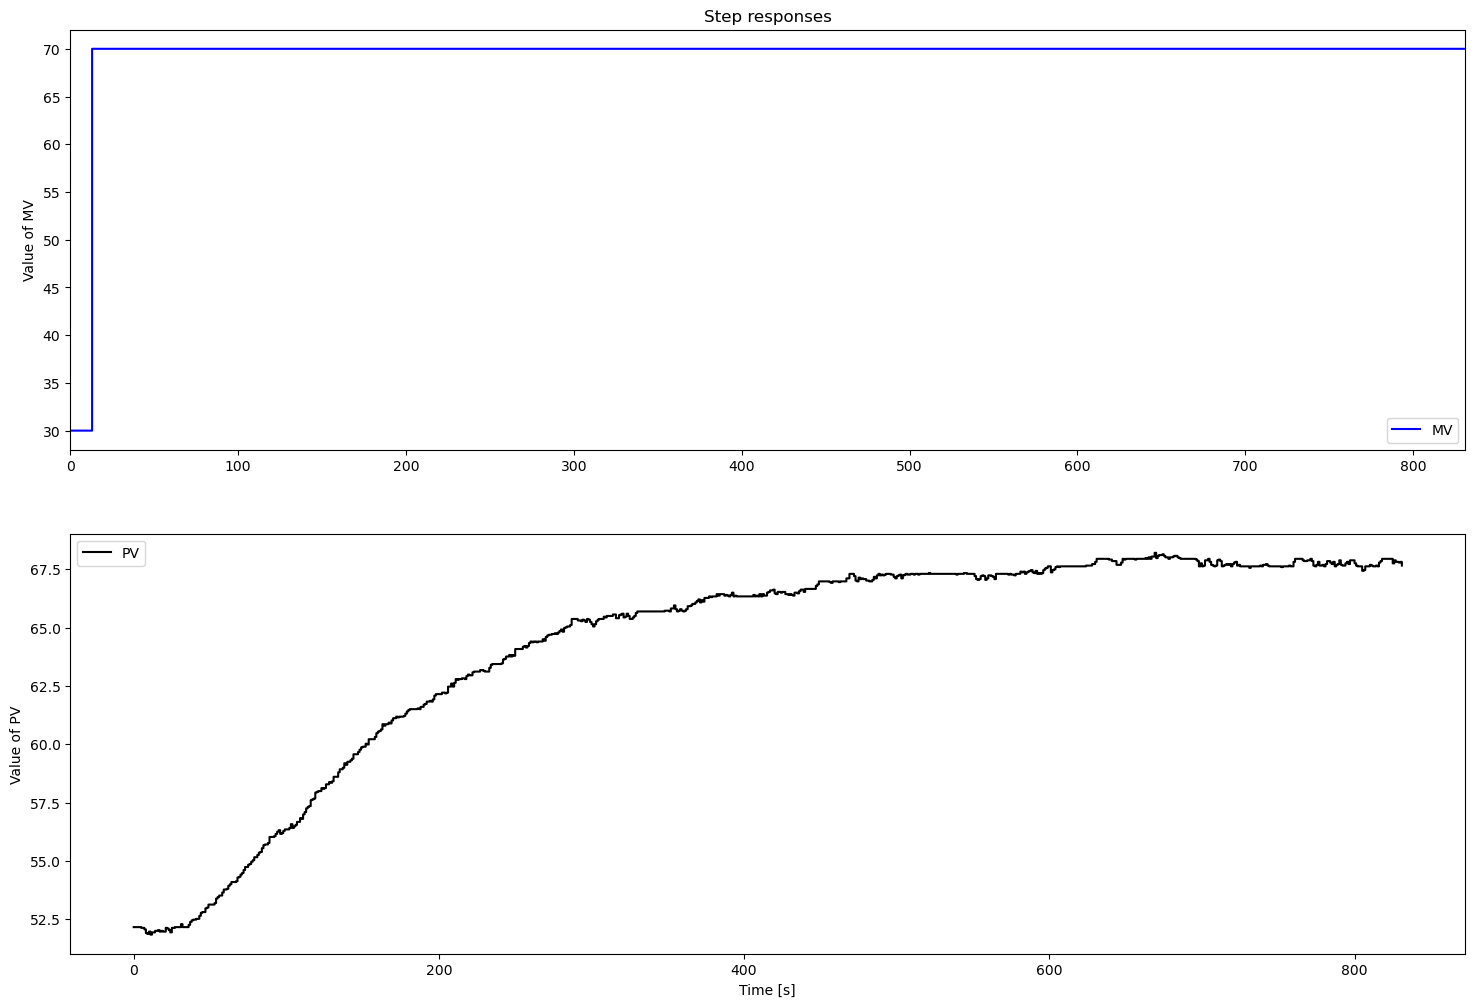

: 

In [ ]:
plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(t)])   
   


ax1.set_xlim(0, t[-1]+1)
ax2.set_xlim(0, t[-1]+1)
plt.subplot(2,1,2)

plt.step(t,PV,'black',label='PV',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  


: 